In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ppghr.io import load_subject, wrist_streams, window_slice, FS_BVP, FS_ACC, FS_ACT, ACTIVITIES

s1 = load_subject(1)
bvp, acc, labels, activity = wrist_streams(s1)
print(len(bvp), len(labels))

589568 4603


In [2]:
def window_activity(i, activity):
    """Activity code for window i, or -1 if the window spans a boundary."""
    seg = window_slice(i, activity, FS_ACT)
    vals = np.unique(seg)
    return -1 if len(vals) > 1 else int(vals[0])

win_act = np.array([window_activity(i, activity) for i in range(len(labels))])

for code in sorted(set(win_act.tolist())):
    name = "mixed" if code == -1 else ACTIVITIES[code]
    count = (win_act == code).sum()
    mean_hr = labels[win_act == code].mean()
    print(f"{name:14s} {count:5d} windows   mean HR {mean_hr:6.1f} bpm")

mixed             52 windows   mean HR   83.4 bpm
transient       1113 windows   mean HR   78.3 bpm
sitting          347 windows   mean HR   51.4 bpm
stairs           140 windows   mean HR  110.4 bpm
table_soccer     169 windows   mean HR   72.5 bpm
cycling          203 windows   mean HR  109.6 bpm
driving          441 windows   mean HR   68.0 bpm
lunch           1174 windows   mean HR   68.3 bpm
walking          373 windows   mean HR   88.6 bpm
working          591 windows   mean HR   71.1 bpm


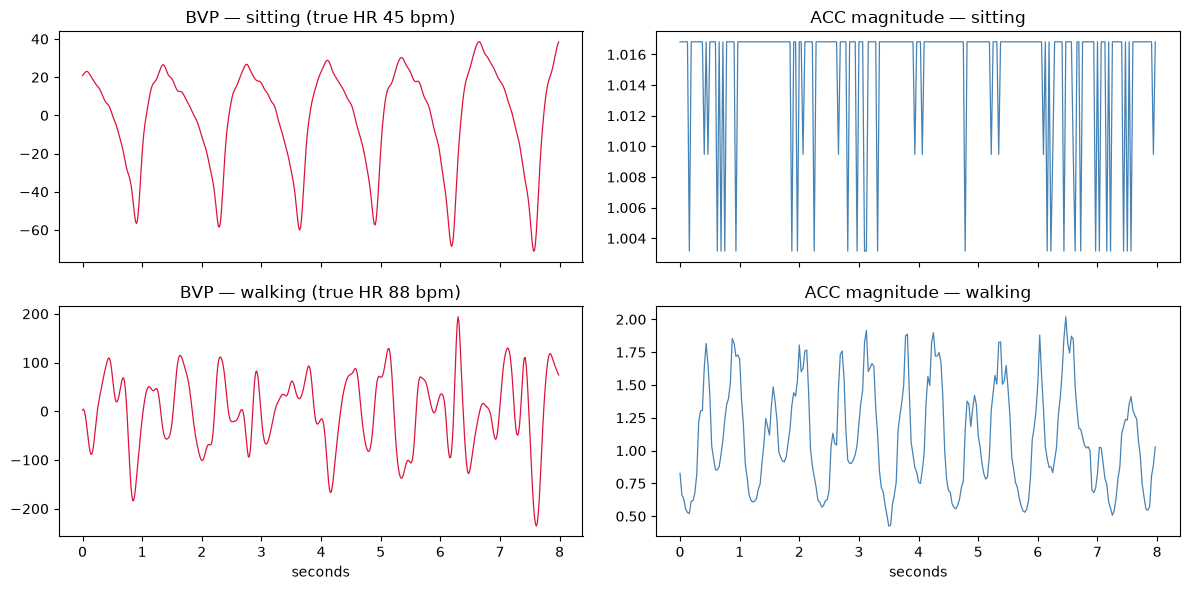

In [3]:
i_sit = np.where(win_act == 1)[0][100]
i_walk = np.where(win_act == 7)[0][100]

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)

for row, (i, name) in enumerate([(i_sit, "sitting"), (i_walk, "walking")]):
    b = window_slice(i, bvp, FS_BVP)
    a = window_slice(i, acc, FS_ACC)
    a_mag = np.linalg.norm(a, axis=1)

    axes[row, 0].plot(np.arange(len(b)) / FS_BVP, b, lw=0.9, color="crimson")
    axes[row, 0].set_title(f"BVP — {name} (true HR {labels[i]:.0f} bpm)")
    axes[row, 1].plot(np.arange(len(a_mag)) / FS_ACC, a_mag, lw=0.9, color="steelblue")
    axes[row, 1].set_title(f"ACC magnitude — {name}")

axes[1, 0].set_xlabel("seconds")
axes[1, 1].set_xlabel("seconds")
plt.tight_layout()
plt.show()

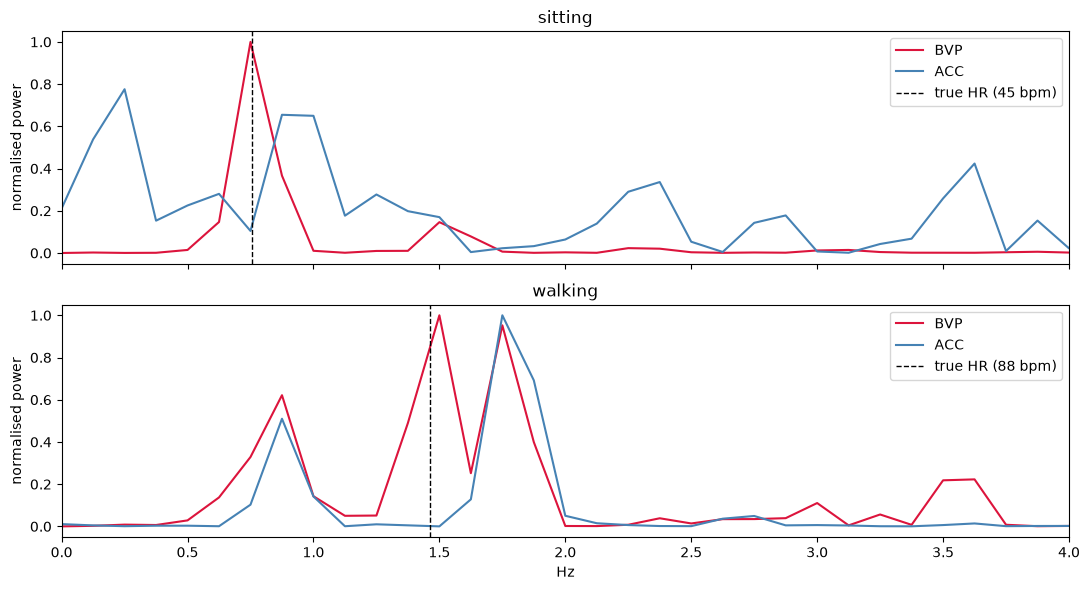

In [4]:
from scipy.signal import welch

def spectrum(x, fs):
    f, p = welch(x, fs=fs, nperseg=len(x), detrend="constant")
    return f, p

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for ax, (i, name) in zip(axes, [(i_sit, "sitting"), (i_walk, "walking")]):
    b = window_slice(i, bvp, FS_BVP)
    a_mag = np.linalg.norm(window_slice(i, acc, FS_ACC), axis=1)

    fb, pb = spectrum(b, FS_BVP)
    fa, pa = spectrum(a_mag, FS_ACC)

    ax.plot(fb, pb / pb.max(), label="BVP", color="crimson")
    ax.plot(fa, pa / pa.max(), label="ACC", color="steelblue")
    ax.axvline(labels[i] / 60, color="black", ls="--", lw=1, label=f"true HR ({labels[i]:.0f} bpm)")
    ax.set_xlim(0, 4)
    ax.set_ylabel("normalised power")
    ax.set_title(name)
    ax.legend()

axes[1].set_xlabel("Hz")
plt.tight_layout()
plt.show()

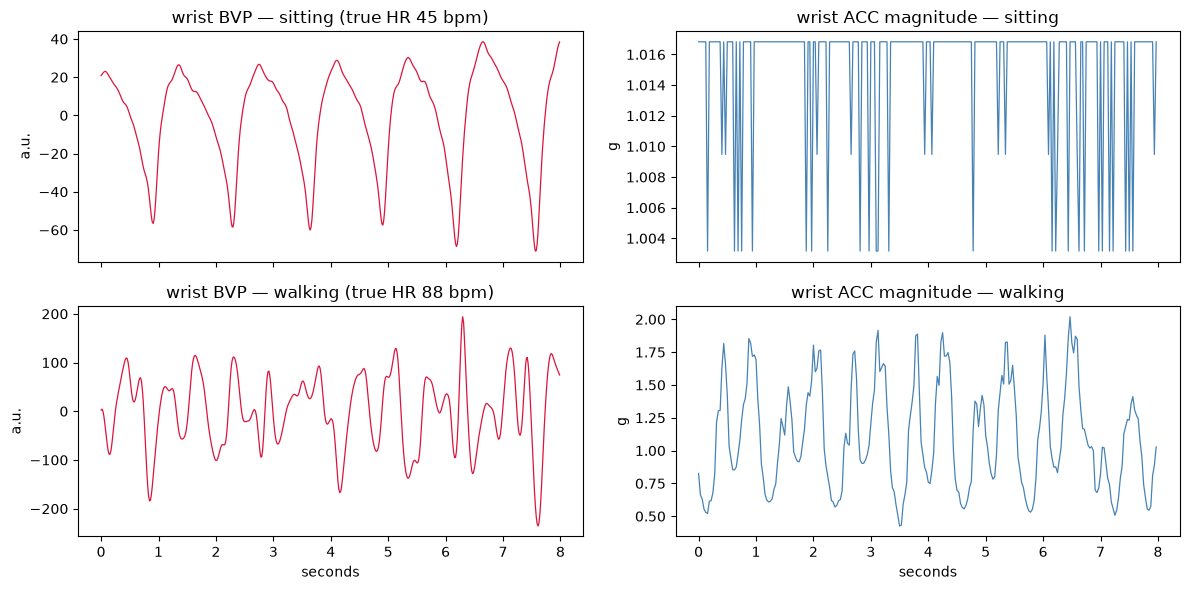

In [5]:
from ppghr.io import load_subject, wrist_streams, window_slice, FS_BVP, FS_ACC, FS_ACT, ACTIVITIES, PROJECT_ROOT

FIG = PROJECT_ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

s1 = load_subject(1)
bvp, acc, labels, activity = wrist_streams(s1)

win_act = np.array([
    (lambda v: -1 if len(v) > 1 else int(v[0]))(np.unique(window_slice(i, activity, FS_ACT)))
    for i in range(len(labels))
])

i_sit = np.where(win_act == 1)[0][100]
i_walk = np.where(win_act == 7)[0][100]

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for row, (i, name) in enumerate([(i_sit, "sitting"), (i_walk, "walking")]):
    b = window_slice(i, bvp, FS_BVP)
    a_mag = np.linalg.norm(window_slice(i, acc, FS_ACC), axis=1)
    axes[row, 0].plot(np.arange(len(b)) / FS_BVP, b, lw=0.9, color="crimson")
    axes[row, 0].set_title(f"wrist BVP — {name} (true HR {labels[i]:.0f} bpm)")
    axes[row, 0].set_ylabel("a.u.")
    axes[row, 1].plot(np.arange(len(a_mag)) / FS_ACC, a_mag, lw=0.9, color="steelblue")
    axes[row, 1].set_title(f"wrist ACC magnitude — {name}")
    axes[row, 1].set_ylabel("g")
axes[1, 0].set_xlabel("seconds")
axes[1, 1].set_xlabel("seconds")
plt.tight_layout()
plt.savefig(FIG / "signal_comparison.png", dpi=150)
plt.show()

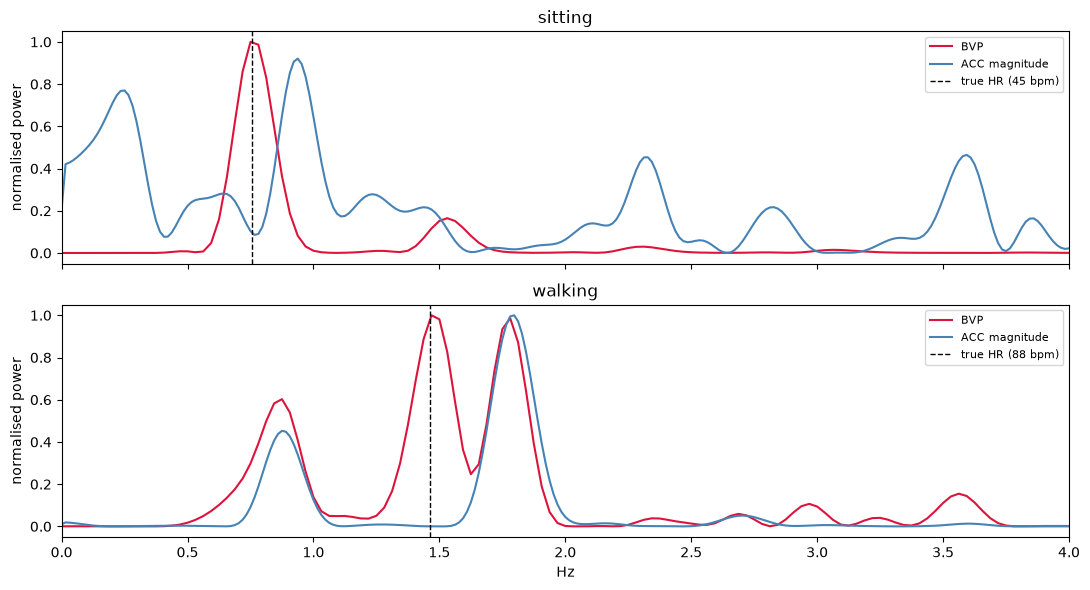

In [6]:
from scipy.signal import welch
from ppghr.baseline import bandpass, spectrum

bvp_f = bandpass(bvp, FS_BVP)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, (i, name) in zip(axes, [(i_sit, "sitting"), (i_walk, "walking")]):
    fb, pb = spectrum(window_slice(i, bvp_f, FS_BVP), FS_BVP)
    a_mag = np.linalg.norm(window_slice(i, acc, FS_ACC), axis=1)
    fa, pa = spectrum(a_mag - a_mag.mean(), FS_ACC)
    ax.plot(fb, pb / pb.max(), color="crimson", label="BVP")
    ax.plot(fa, pa / pa.max(), color="steelblue", label="ACC magnitude")
    ax.axvline(labels[i] / 60, color="black", ls="--", lw=1,
               label=f"true HR ({labels[i]:.0f} bpm)")
    ax.set_xlim(0, 4)
    ax.set_ylabel("normalised power")
    ax.set_title(name)
    ax.legend(fontsize=8)
axes[1].set_xlabel("Hz")
plt.tight_layout()
plt.savefig(FIG / "spectra.png", dpi=150)
plt.show()